In [1]:
import torch

AA_TYPES = [
    "ALA","ARG","ASN","ASP","CYS","GLN","GLU","GLY","HIS",
    "ILE","LEU","LYS","MET","PHE","PRO","SER","THR","TRP","TYR","VAL"
]

ELEM_TYPES = ["H","C","N","O","S","P","F","Cl","Br","I"]

def load_pocket(pdb_path):
    coords = []
    feats = []

    with open(pdb_path) as f:
        for line in f:
            if not line.startswith("ATOM"):
                continue
            x = float(line[30:38])
            y = float(line[38:46])
            z = float(line[46:54])
            resname = line[17:20].strip()
            elem = line[76:78].strip() or line[12:16].strip()[0]

            aa_onehot = torch.zeros(len(AA_TYPES))
            if resname in AA_TYPES:
                aa_onehot[AA_TYPES.index(resname)] = 1.0

            elem_onehot = torch.zeros(len(ELEM_TYPES))
            if elem in ELEM_TYPES:
                elem_onehot[ELEM_TYPES.index(elem)] = 1.0

            coords.append([x,y,z])
            feats.append(torch.cat([aa_onehot, elem_onehot]))

    pocket_pos = torch.tensor(coords, dtype=torch.float32)
    pocket_x   = torch.stack(feats, dim=0)  # [N_pocket, F_pocket]
    return pocket_pos, pocket_x


In [2]:
from rdkit import Chem
import torch

LIG_ELEMS = ["H","C","N","O","S","P","F","Cl","Br","I"]

def atom_features(atom):
    sym = atom.GetSymbol()
    elem_oh = torch.zeros(len(LIG_ELEMS))
    if sym in LIG_ELEMS:
        elem_oh[LIG_ELEMS.index(sym)] = 1.0

    extra = torch.tensor([
        atom.GetAtomicNum(),
        atom.GetTotalDegree(),
        int(atom.GetIsAromatic()),
        atom.GetFormalCharge(),
    ], dtype=torch.float32)

    return torch.cat([elem_oh, extra], dim=0)

def mol_to_ligand_tensors(mol, pred_pos):
    n_atoms = mol.GetNumAtoms()
    assert pred_pos.shape[0] == n_atoms

    pos = torch.from_numpy(pred_pos).float()     # [N, 3]
    xs  = [atom_features(a) for a in mol.GetAtoms()]
    x   = torch.stack(xs, dim=0)                 # [N, F]
    return pos, x


In [3]:
from torch.utils.data import Dataset
from rdkit import Chem

class LigandPocketDataset(Dataset):
    def __init__(self,
                 sdf_path,
                 pdb_path,
                 use_vina=True,
                 csv_path=None,
                 csv_key="SMILES",
                 csv_value="affinity"):

        self.supplier = Chem.SDMolSupplier(sdf_path, removeHs=False)
        self.ligand_indices = [i for i, m in enumerate(self.supplier) if m is not None]

        self.pocket_pos, self.pocket_x = load_pocket(pdb_path)

        self.use_vina = use_vina
        if not use_vina:
            assert csv_path is not None, "Need CSV for real affinities if not using Vina"
            self.smiles_to_affinity = load_affinity_csv(csv_path, key=csv_key,
                                                        value_col=csv_value)

    def __len__(self):
        return len(self.ligand_indices)

    def __getitem__(self, idx):
        i = self.ligand_indices[idx]
        mol = self.supplier[i]
        if mol is None:
            raise RuntimeError("RDKit returned None, dataset is corrupted")

        lig_pos, lig_x = mol_to_tensors(mol)

        if self.use_vina:
            y = get_label_from_sdf(mol, prop_name="Vina_Dock")
        else:
            y = get_label_from_csv(mol, self.smiles_to_affinity)

        # Optionally recenter around pocket / ligand here
        return {
            "ligand_pos": lig_pos,
            "ligand_x":   lig_x,
            "pocket_pos": self.pocket_pos,
            "pocket_x":   self.pocket_x,
            "y":          y,
        }


In [4]:
AA_TYPES = [
    "ALA","ARG","ASN","ASP","CYS","GLN","GLU","GLY","HIS",
    "ILE","LEU","LYS","MET","PHE","PRO","SER","THR","TRP","TYR","VAL"
]
ELEM_TYPES = ["H","C","N","O","S","P","F","Cl","Br","I"]

def load_pocket(pdb_path):
    coords, feats = [], []

    with open(pdb_path) as f:
        for line in f:
            if not line.startswith("ATOM"):
                continue
            x = float(line[30:38]); y = float(line[38:46]); z = float(line[46:54])
            res = line[17:20].strip()
            elem = line[76:78].strip() or line[12:16].strip()[0]

            aa_oh = torch.zeros(len(AA_TYPES))
            if res in AA_TYPES:
                aa_oh[AA_TYPES.index(res)] = 1.0

            el_oh = torch.zeros(len(ELEM_TYPES))
            if elem in ELEM_TYPES:
                el_oh[ELEM_TYPES.index(elem)] = 1.0

            coords.append([x, y, z])
            feats.append(torch.cat([aa_oh, el_oh]))

    pocket_pos = torch.tensor(coords, dtype=torch.float32)
    pocket_x   = torch.stack(feats, dim=0)
    return pocket_pos, pocket_x


In [5]:
import torch
from torch.utils.data import Dataset
from torch_geometric.data import Data
from pathlib import Path

class LigandPocketFromPT(Dataset):
    def __init__(self, pt_path=None, pt_dir=None, pdb_path=None, vina_mode="dock", max_affinity=None):
        import torch

        assert pdb_path is not None, "pdb_path is required"
        assert (pt_path is not None) or (pt_dir is not None), "Provide pt_path or pt_dir"

        results = []
        pt_files = []
        if pt_dir is not None:
            for p in sorted(Path(pt_dir).glob("*.pt")):
                obj = torch.load(p, map_location="cpu", weights_only=False)
                results.extend(obj["all_results"])
                pt_files.append(p)
        else:
            obj = torch.load(pt_path, map_location="cpu", weights_only=False)
            results.extend(obj["all_results"])
            pt_files.append(pt_path)

        self.results = results
        self.pt_files = pt_files
        self.pocket_pos, self.pocket_x = load_pocket(pdb_path)

        assert vina_mode in ["dock", "minimize", "score_only"]
        self.vina_mode = vina_mode
        self.max_affinity = max_affinity

        if max_affinity is None:
            self.indices = list(range(len(self.results)))
        else:
            self.indices = [
                i for i, r in enumerate(self.results)
                if r["vina"][self.vina_mode][0]["affinity"] <= max_affinity
            ]
            if len(self.indices) == 0:
                raise ValueError("All samples filtered out; relax max_affinity")

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        rec = self.results[self.indices[idx]]

        mol      = rec["mol"]
        pred_pos = rec["pred_pos"]
        chem     = rec["chem_results"]
        vina_rec = rec["vina"][self.vina_mode][0]

        lig_pos, lig_x = mol_to_ligand_tensors(mol, pred_pos)

        # scalar targets / descriptors
        y   = torch.tensor([vina_rec["affinity"]], dtype=torch.float32)
        qed = torch.tensor([chem["qed"]], dtype=torch.float32)
        sa  = torch.tensor([chem["sa"]], dtype=torch.float32)
        logp = torch.tensor([chem["logp"]], dtype=torch.float32)

        # atomic numbers for PyG convenience (stored in lig_x extra features)
        z = lig_x[:, len(LIG_ELEMS)].long()

        return Data(
            pos=lig_pos,
            x=lig_x,
            z=z,
            y=y,
            pocket_pos=self.pocket_pos,
            pocket_x=self.pocket_x,
            qed=qed,
            sa=sa,
            logp=logp,
            smiles=rec["smiles"],
        )


In [97]:
# Using PyG default collate (Batch.from_data_list)


In [6]:
ds = LigandPocketFromPT(
    pt_dir="metrics_dir",
    pdb_path="y220c_pocket10.pdb",
    vina_mode="dock",
    max_affinity=0.0
)

# Inspect a sample
print(len(ds), "graphs loaded")
print(ds[0])
print("y (binding affinity):", ds[0].y)


14690 graphs loaded
Data(x=[6, 14], y=[1], pos=[6, 3], z=[6], pocket_pos=[265, 3], pocket_x=[265, 30], qed=[1], sa=[1], logp=[1], smiles='O=C(O)C(=O)O')
y (binding affinity): tensor([-2.6730])


In [7]:
from torch.utils.data import random_split
from torch_geometric.loader import DataLoader as PyGDataLoader


In [8]:
n_total = len(ds)
n_test  = int(0.1 * n_total)
n_val   = int(0.1 * n_total)
n_train = n_total - n_val - n_test

train_dataset, val_dataset, test_dataset = random_split(
    ds,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(0),
)

train_loader = PyGDataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = PyGDataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = PyGDataLoader(test_dataset,  batch_size=32, shuffle=False)


In [9]:
print(len(ds), "graphs loaded")
print(ds[0])
print("y (binding affinity):", ds[0].y)

14690 graphs loaded
Data(x=[6, 14], y=[1], pos=[6, 3], z=[6], pocket_pos=[265, 3], pocket_x=[265, 30], qed=[1], sa=[1], logp=[1], smiles='O=C(O)C(=O)O')
y (binding affinity): tensor([-2.6730])


In [18]:
HIDDEN = 128   # hidden width for atom encoder / readout
DROPOUT = 0.1

MLP

In [103]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.utils import scatter

In [104]:
class AtomEncoder(nn.Module):
    def __init__(self, in_dim: int, hidden: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
class BindingAffinityMLP(nn.Module):
    def __init__(self, max_z: int = 100, hidden: int = HIDDEN):
        super().__init__()
        self.emb = nn.Embedding(max_z, hidden)
        # input per atom: embedding + xyz (3)
        self.atom_encoder = AtomEncoder(hidden + 3, hidden)
        # graph-level readout to binding affinity (scalar)
        self.readout = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Linear(64, 1),  # predict affinity
        )

    def forward(self, data):
        pos = data.pos          # [N, 3]
        z = data.z              # [N]
        batch = data.batch      # [N]

        x = torch.cat([self.emb(z), pos], dim=-1)  # [N, hidden+3]
        h = self.atom_encoder(x)                   # [N, hidden]

        # mean-pool over atoms per graph
        g = scatter(h, batch, dim=0, reduce="mean")  # [B, hidden]

        affinity = self.readout(g).squeeze(-1)     # [B]
        return affinity


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EquivariantAffinityModel(max_z=100).to(device)
opt = torch.optim.Adam(model.parameters(), lr=3e-4)


GNN

Need this function for regular gnn and equivariant gnn

In [22]:
import torch

def build_radius_edge_index(pos: torch.Tensor, batch: torch.Tensor = None, r: float = 5.0, loop: bool = False):
    """
    Pure PyTorch radius graph that respects batch.
    pos: [N, 3]
    batch: [N] or None
    returns edge_index: [2, E]
    """
    if batch is None:
        batch = torch.zeros(pos.size(0), dtype=torch.long, device=pos.device)

    edge_src = []
    edge_dst = []

    for b in batch.unique():
        mask = batch == b
        idx = mask.nonzero(as_tuple=True)[0]
        sub_pos = pos[idx]

        dist = torch.cdist(sub_pos, sub_pos, p=2)
        sub_mask = dist <= r
        if not loop:
            sub_mask = sub_mask & ~torch.eye(len(idx), dtype=torch.bool, device=pos.device)

        src, dst = sub_mask.nonzero(as_tuple=True)
        edge_src.append(idx[src])
        edge_dst.append(idx[dst])

    edge_index = torch.stack([torch.cat(edge_src), torch.cat(edge_dst)], dim=0)
    return edge_index


this dont need for equivariant gnn

In [120]:
class SimpleMPBlock(nn.Module):
    def __init__(self, hidden: int):
        super().__init__()
        # message MLP takes source, target, and distance
        self.msg_mlp = nn.Sequential(
            nn.Linear(2 * hidden + 1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
        )
        # update MLP mixes old node state + aggregated message
        self.update = nn.Sequential(
            nn.Linear(hidden + hidden, hidden),
            nn.ReLU(),
        )

    def forward(self, x, pos, edge_index):
        row, col = edge_index  # row=dst, col=src
        rel = pos[col] - pos[row]
        dist = rel.norm(dim=-1, keepdim=True)  # [E,1]

        m_in = torch.cat([x[col], x[row], dist], dim=-1)  # [E, 2H+1]
        m_ij = self.msg_mlp(m_in)                        # [E, H]

        m_i = scatter(m_ij, row, dim=0, dim_size=x.size(0), reduce="mean")  # [N,H]
        x_out = self.update(torch.cat([x, m_i], dim=-1))
        return x_out


In [121]:
class MessagePassingAffinityModel(nn.Module):
    def __init__(self, max_z: int = 100, hidden: int = HIDDEN, n_layers: int = 3, radius: float = 5.0):
        super().__init__()
        self.emb = nn.Embedding(max_z, hidden)
        self.lin_in = nn.Linear(hidden + 3, hidden)

        self.layers = nn.ModuleList([SimpleMPBlock(hidden) for _ in range(n_layers)])
        self.readout = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(hidden, 1),  # predict binding affinity (scalar)
        )
        self.radius = radius

    def forward(self, data):
        pos = data.pos
        z = data.z
        batch = data.batch
        edge_index = getattr(data, "edge_index", None)

        # build a radius graph on-the-fly if not provided
        if edge_index is None:
            edge_index = build_radius_edge_index(pos, batch=batch, r=self.radius).to(pos.device)

        # center the ligand for stability
        center = scatter(pos, batch, dim=0, reduce="mean")
        pos_rel = pos - center[batch]

        x = torch.cat([self.emb(z), pos_rel], dim=-1)
        x = self.lin_in(x)

        for layer in self.layers:
            x = layer(x, pos_rel, edge_index)

        # mean-pool over all nodes (ligand-only graph)
        g = scatter(x, batch, dim=0, reduce="mean")  # [B, hidden]
        affinity = self.readout(g).squeeze(-1)        # [B]
        return affinity


In [139]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MessagePassingAffinityModel(max_z=100).to(device)
opt = torch.optim.Adam(model.parameters(), lr=3e-3)


SE(3)-Equivariant GNN

In [13]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.utils import scatter

from e3nn import o3
from e3nn.nn import Gate

In [14]:
# Node feature irreps: 32 scalars + 32 vectors
IRREPS_NODE   = o3.Irreps("32x0e + 32x1o")

# For the Gate inside blocks: split into
#   32 scalars  |  32 gate scalars  | 32 vectors
IRREPS_GATE_IN = o3.Irreps("32x0e + 32x0e + 32x1o")

# Per-node scalar channels used for graph readout
IRREPS_OUT    = o3.Irreps("32x0e")

# Spherical harmonics of degree 1 -> one 1o irrep
IRREPS_SH     = o3.Irreps("1x1o")


In [15]:
class EquivariantMPBlock(nn.Module):
    def __init__(self):
        super().__init__()

        # Mix node features into scalars / gate scalars / vectors
        self.lin_node = o3.Linear(
            irreps_in=IRREPS_NODE,
            irreps_out=IRREPS_GATE_IN,
        )

        self.gate = Gate(
            irreps_scalars="32x0e",
            act_scalars=[F.relu],          # broadcast over multiplicity
            irreps_gates="32x0e",
            act_gates=[torch.sigmoid],
            irreps_gated="32x1o",
        )

        # Tensor product between node features and spherical harmonics on edges
        # message_{i<-j} = TP( x_j , Y^1(r_ij) )  -> IRREPS_NODE
        self.tp_msg = o3.FullyConnectedTensorProduct(
            irreps_in1=IRREPS_NODE,
            irreps_in2=IRREPS_SH,
            irreps_out=IRREPS_NODE,
        )

        # Optional extra mixing on aggregated messages
        self.lin_msg = o3.Linear(
            irreps_in=IRREPS_NODE,
            irreps_out=IRREPS_NODE,
        )

        self.norm = nn.LayerNorm(IRREPS_NODE.dim)


    def forward(self, x, pos, edge_index):
        """
        x:   [N, IRREPS_NODE.dim] node features
        pos: [N, 3] positions
        edge_index: [2, E] with edges (src=j, dst=i)
        """
        row, col = edge_index  # row = dst (i), col = src (j)

        # Prepare node features for gating
        h = self.lin_node(x)          # [N, IRREPS_GATE_IN.dim]
        h = self.gate(h)              # [N, IRREPS_NODE.dim] again

        # Relative vectors per edge
        rel = pos[col] - pos[row]     # [E, 3]

        # Spherical harmonics Y^1(r_ij) -> 1x1o, shape [E, 3]
        sh = o3.spherical_harmonics(
            l=1,
            x=rel,
            normalize=True,
            normalization='component',
        )  # [E, 3]

        # Messages from j to i
        m_ij = self.tp_msg(h[col], sh)   # [E, IRREPS_NODE.dim]

        # Aggregate messages at destination nodes
        # m_i = scatter(m_ij, row, dim=0, dim_size=x.shape[0], reduce="sum")
        # m_i = scatter(m_ij, row, dim=0, dim_size=x.shape[0], reduce="mean")

        # after computing m_ij
        deg = scatter(torch.ones_like(row, dtype=m_ij.dtype), row, dim=0, dim_size=x.size(0), reduce="sum").clamp(min=1.0)
        m_i = scatter(m_ij, row, dim=0, dim_size=x.size(0), reduce="sum")
        m_i = m_i / deg.unsqueeze(-1)  # or / deg.sqrt().unsqueeze(-1)

        
        # Mix + residual
        m_i = self.lin_msg(m_i)
        m_i = self.norm(m_i) # ADD LAYER NORM

        x_out = x + m_i

        return x_out

In [16]:
class EquivariantAffinityModel(nn.Module):
    def __init__(self, max_z: int = 100, n_layers: int = 3, radius: float = 5.0):
        super().__init__()

        # Embed atomic number -> scalar channels
        self.emb = nn.Embedding(max_z, 16)
 
        # First linear: (16x0e + 1x1o) -> IRREPS_NODE
        self.irreps_in = o3.Irreps("16x0e + 1x1o")

        self.lin_in = o3.Linear(
            irreps_in=self.irreps_in,
            irreps_out=IRREPS_NODE,
        )

        # Stack of message passing blocks
        self.layers = nn.ModuleList(
            [EquivariantMPBlock() for _ in range(n_layers)]
        )

        # Map node features to scalar channels, then graph-level MLP head
        self.lin_out = o3.Linear(
            irreps_in=IRREPS_NODE,
            irreps_out=IRREPS_OUT,
        )
        self.readout = nn.Sequential(
            nn.Linear(IRREPS_OUT.dim, HIDDEN),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN, 1),
        )
        self.radius = radius

    def forward(self, data):
        pos = data.pos          # [N, 3]
        z = data.z              # [N]
        batch = data.batch      # [N]
        edge_index = getattr(data, "edge_index", None)  # [2, E] or None

        # Build a radius graph on-the-fly if not provided
        if edge_index is None:
            edge_index = build_radius_edge_index(pos, batch=batch, r=self.radius).to(pos.device)

        # Center each molecule (translation invariance)
        # should i be centering? it's supposed to be equivariant, not invariant
        center = scatter(pos, batch, dim=0, reduce="mean")   # [B, 3]
        pos_rel = (pos - center[batch])

        # Input features: scalars from embedding + vector from position
        scalars = self.emb(z)                                # [N, 16]
        x_in = torch.cat([scalars, pos_rel], dim=-1)         # [N, 16+3]

        # Map to hidden irreps
        x = self.lin_in(x_in)                                # [N, IRREPS_NODE.dim]

        # Message passing layers
        for layer in self.layers:
            x = layer(x, pos_rel, edge_index)

        # Per-node scalar channels -> pool over nodes for graph representation
        node_scalars = self.lin_out(x)                        # [N, IRREPS_OUT.dim]
        g = scatter(node_scalars, batch, dim=0, reduce="mean")  # [B, IRREPS_OUT.dim]

        affinity = self.readout(g).squeeze(-1)                # [B]
        return affinity


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EquivariantAffinityModel(max_z=100).to(device)
opt = torch.optim.Adam(model.parameters(), lr=3e-3)

Helper to evaluate loss

In [20]:
def eval_loader(loader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            pred = model(data)                           # [B]
            true = data.y.to(pred.dtype).view(-1)        # [B]
            loss = F.mse_loss(pred, true)
            total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)
    


training loop

In [23]:
for epoch in range(30):  # bump this up later
    model.train()
    total_loss = 0.0

    for data in train_loader:
        data = data.to(device)
        pred = model(data)                           # [B]
        true = data.y.to(pred.dtype).view(-1)        # [B]
        loss = F.mse_loss(pred, true)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item() * data.num_graphs

    val_loss = eval_loader(val_loader)
    avg_loss = total_loss / len(train_loader.dataset)
    print(f"epoch {epoch}, train_loss={avg_loss:.4f}, val_loss={val_loss:.4f}")


epoch 0, train_loss=0.5033, val_loss=0.1689
epoch 1, train_loss=0.2459, val_loss=0.1867


KeyboardInterrupt: 

In [155]:
# 1) Check label stats

preds = []
for d in ds:
    preds.append(torch.norm(d.y))
preds = torch.stack(preds)
print("True: min", preds.min().item(),
      "max", preds.max().item(),
      "mean", preds.mean().item())

# 2) Check one batch while training/eval
data = next(iter(train_loader)).to(device)
pred = model(data)


true = data.y.to(pred.dtype).view(-1)   
print("pred:", pred[:8])
print("true:", true[:8])
print("loss:", F.mse_loss(pred, true).item())



True: min 0.004999999888241291 max 8.949999809265137 mean 4.802018165588379
pred: tensor([-5.4003, -4.7554, -6.3364, -4.9990, -5.4408, -5.7803, -4.8969, -4.9312],
       device='cuda:0', grad_fn=<SliceBackward0>)
true: tensor([-4.8540, -4.9150, -5.7520, -4.4520, -5.4010, -5.0830, -4.8040, -5.2860],
       device='cuda:0')
loss: 0.12233959883451462


In [156]:
def collect_preds(model, loader, device):
    model.eval()
    ys = []
    ys_pred = []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            pred = model(data)   # [B], [B, 3]

            true = data.y.to(pred.dtype).view(-1)   

            ys.append(true.cpu())                # each is [B]
            ys_pred.append(pred.cpu())           # each is [B]

    ys = torch.cat(ys, dim=0)                           # [N_test]
    ys_pred = torch.cat(ys_pred, dim=0)
    return ys, ys_pred


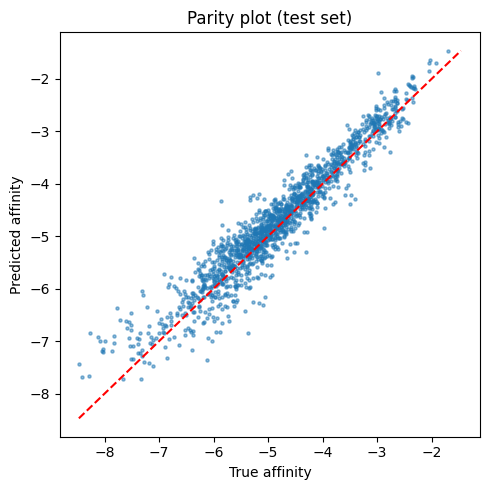

In [158]:
import matplotlib.pyplot as plt

ys, ys_pred = collect_preds(model, test_loader, device)

plt.figure(figsize=(5,5))
plt.scatter(ys, ys_pred, s=5, alpha=0.5)
min_v = min(ys.min().item(), ys_pred.min().item())
max_v = max(ys.max().item(), ys_pred.max().item())
plt.plot([min_v, max_v], [min_v, max_v], 'r--')  # ideal y=x line
plt.xlabel("True affinity")
plt.ylabel("Predicted affinity")
plt.title("Parity plot (test set)")
plt.tight_layout()
plt.show()

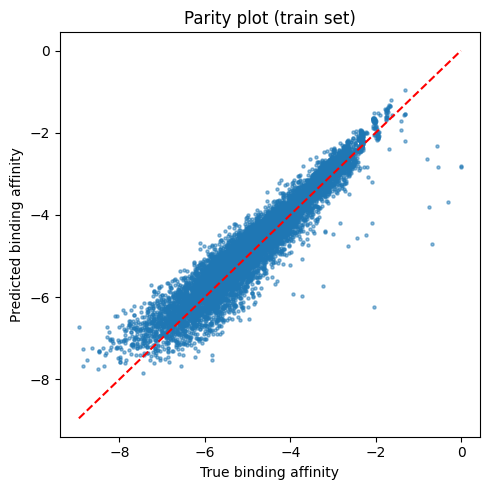

In [159]:
import matplotlib.pyplot as plt

ys_train, ys_pred_train = collect_preds(model, train_loader, device)

plt.figure(figsize=(5,5))
plt.scatter(ys_train, ys_pred_train, s=5, alpha=0.5)
min_v = min(ys_train.min().item(), ys_pred_train.min().item())
max_v = max(ys_train.max().item(), ys_pred_train.max().item())
plt.plot([min_v, max_v], [min_v, max_v], 'r--')  # ideal y=x line
plt.xlabel("True binding affinity")
plt.ylabel("Predicted binding affinity")
plt.title("Parity plot (train set)")
plt.tight_layout()
plt.show()

In [164]:
mae = torch.mean(torch.abs(ys_pred - ys)).item()
print("Test MAE:", f"{mae:.4f}")

Test MAE: 0.2754
